LIBRARY

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings("ignore")

plt.style.use('ggplot')

DATASET

In [2]:
from google.colab import files

uploaded = files.upload()

Saving StudentPerformanceFactors.csv to StudentPerformanceFactors.csv


In [3]:
df = pd.read_csv("StudentPerformanceFactors.csv")

READ DATASET

In [4]:
df.head()
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

(6607, 20)

MISSING VALUE

In [5]:
df.isnull().sum()
df.fillna(df.mode().iloc[0], inplace=True)

KPI

In [6]:
total_siswa = len(df)

rata_nilai = df["Exam_Score"].mean()

rata_kehadiran = df["Attendance"].mean()

rata_belajar = df["Hours_Studied"].mean()

In [7]:
print("Total Siswa :", total_siswa)
print("Nilai Rata-rata :", round(rata_nilai,2))
print("Kehadiran :", round(rata_kehadiran,2))
print("Jam Belajar :", round(rata_belajar,2))

Total Siswa : 6607
Nilai Rata-rata : 67.24
Kehadiran : 79.98
Jam Belajar : 19.98


VISUALISASI 1

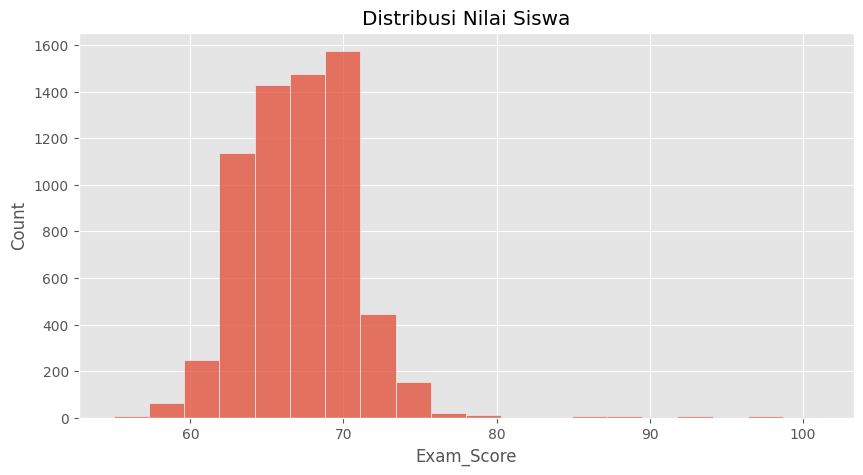

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(df["Exam_Score"], bins=20)

plt.title("Distribusi Nilai Siswa")

plt.show()

VISUALISASI 2

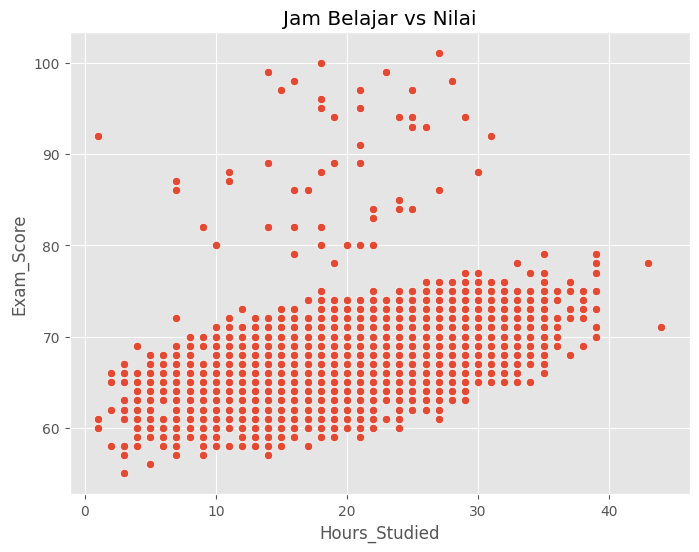

In [9]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Hours_Studied",
    y="Exam_Score",
    data=df
)

plt.title("Jam Belajar vs Nilai")

plt.show()

VISUALISASI 3

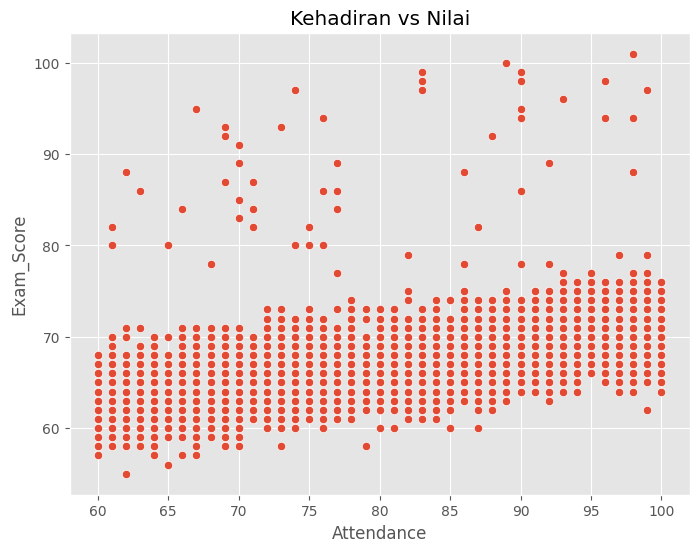

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Attendance",
    y="Exam_Score",
    data=df
)

plt.title("Kehadiran vs Nilai")

plt.show()

VISUALISASI 4

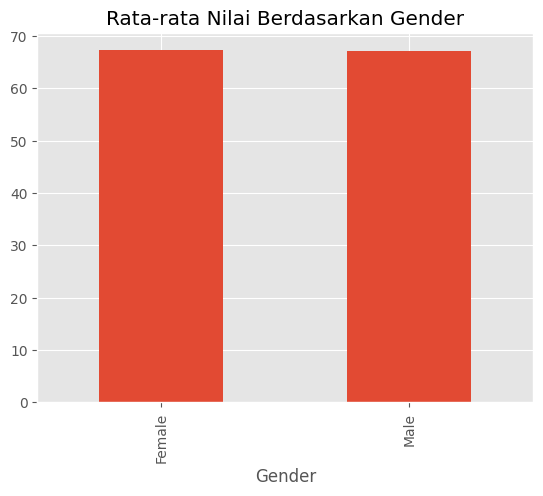

In [11]:
gender = df.groupby("Gender")["Exam_Score"].mean()

gender.plot(kind="bar")

plt.title("Rata-rata Nilai Berdasarkan Gender")

plt.show()

VISUALISASI 5

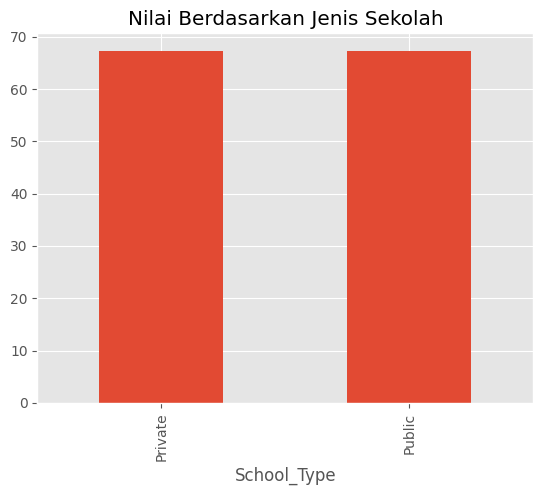

In [12]:
school = df.groupby("School_Type")["Exam_Score"].mean()

school.plot(kind="bar")

plt.title("Nilai Berdasarkan Jenis Sekolah")

plt.show()

VISUALIASASI 6

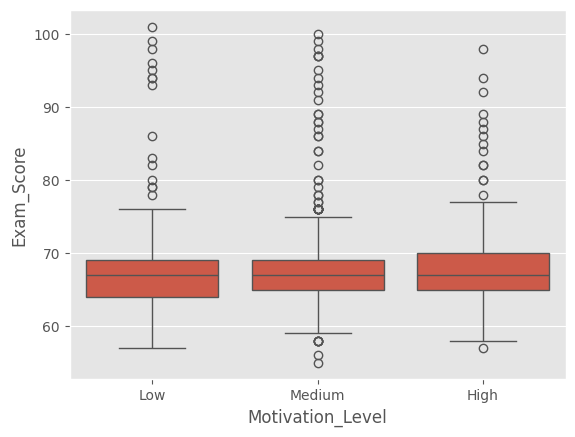

In [13]:
sns.boxplot(
    x="Motivation_Level",
    y="Exam_Score",
    data=df
)

plt.show()

VISUALISASI 7

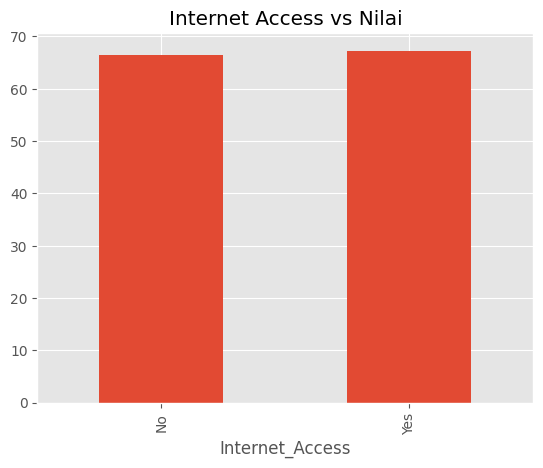

In [14]:
internet = df.groupby("Internet_Access")["Exam_Score"].mean()

internet.plot(kind="bar")

plt.title("Internet Access vs Nilai")

plt.show()

KORELASI

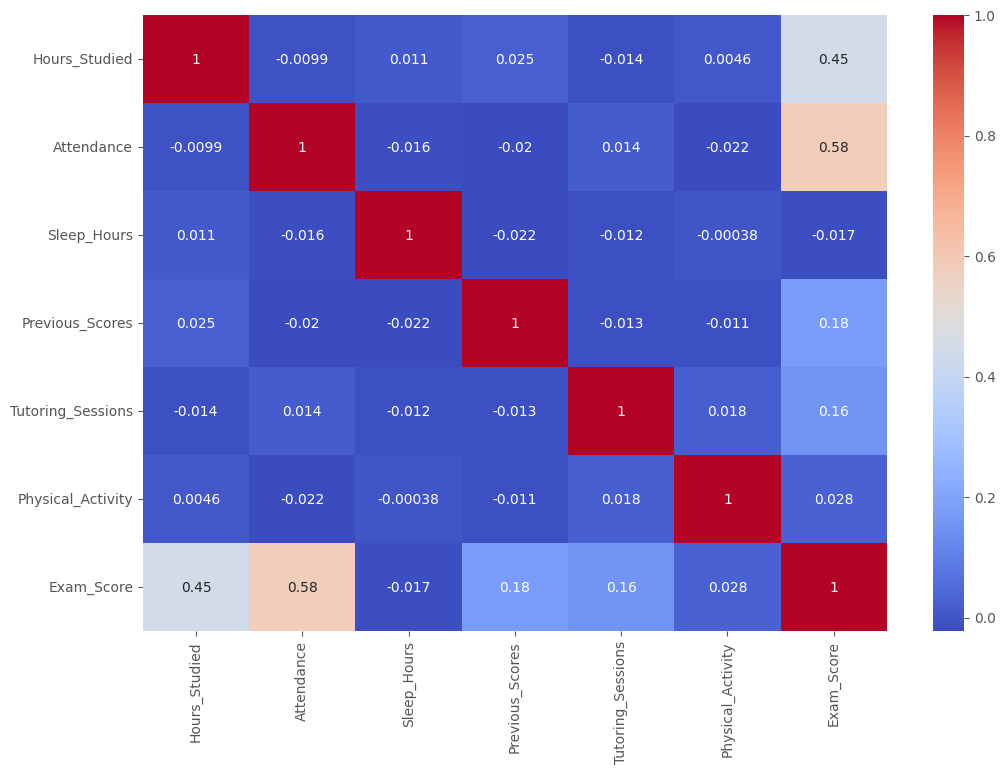

In [15]:
numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

FAKTOR PENGARUH

In [16]:
df_ml = df.copy()

le = LabelEncoder()

for col in df_ml.select_dtypes(include="object").columns:
    df_ml[col] = le.fit_transform(df_ml[col])

In [17]:
X = df_ml.drop("Exam_Score", axis=1)
y = df_ml["Exam_Score"]

In [18]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X, y)

RandomForestRegressor(random_state=42)

In [19]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

VISUALISASI PENGARUH

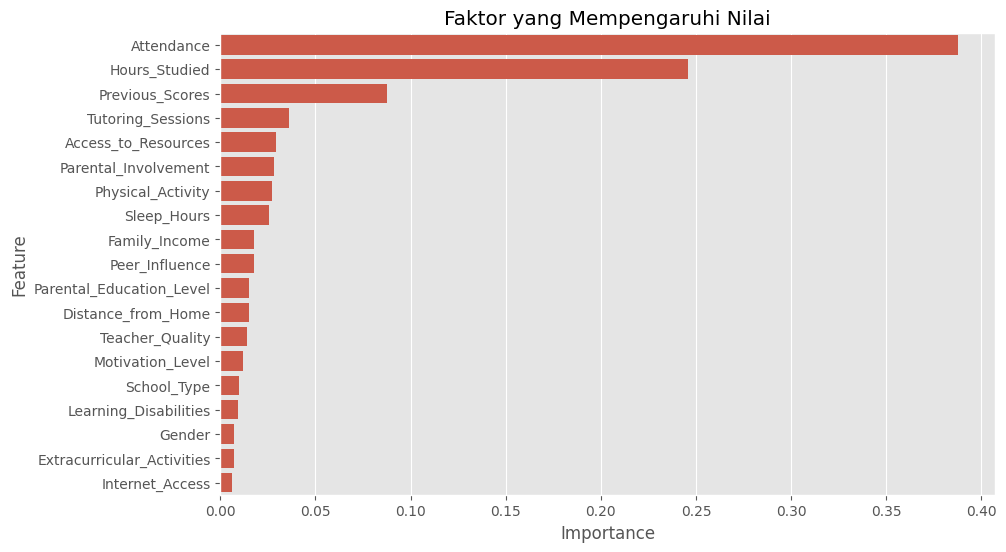

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Faktor yang Mempengaruhi Nilai")

plt.show()